<a href="https://colab.research.google.com/github/dhengekrunal-ai/-rohit/blob/main/practcal_1_roll_42_EE26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express
from sklearn.model_selection import train_test_split
import plotly.express as px
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [ ]:
import pandas as pd
df =pd.read_csv('/content/retail_sales_dataset (1) (1).csv')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


In [ ]:
df.info(), df.head(), df.tail()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


(None,
    Transaction ID        Date Customer ID  Gender  Age Product Category  \
 0               1  2023-11-24     CUST001    Male   34           Beauty   
 1               2  2023-02-27     CUST002  Female   26         Clothing   
 2               3  2023-01-13     CUST003    Male   50      Electronics   
 3               4  2023-05-21     CUST004    Male   37         Clothing   
 4               5  2023-05-06     CUST005    Male   30           Beauty   
 
    Quantity  Price per Unit  Total Amount  
 0         3              50           150  
 1         2             500          1000  
 2         1              30            30  
 3         1             500           500  
 4         2              50           100  ,
      Transaction ID        Date Customer ID  Gender  Age Product Category  \
 995             996  2023-05-16     CUST996    Male   62         Clothing   
 996             997  2023-11-17     CUST997    Male   52           Beauty   
 997             998  2023-10-

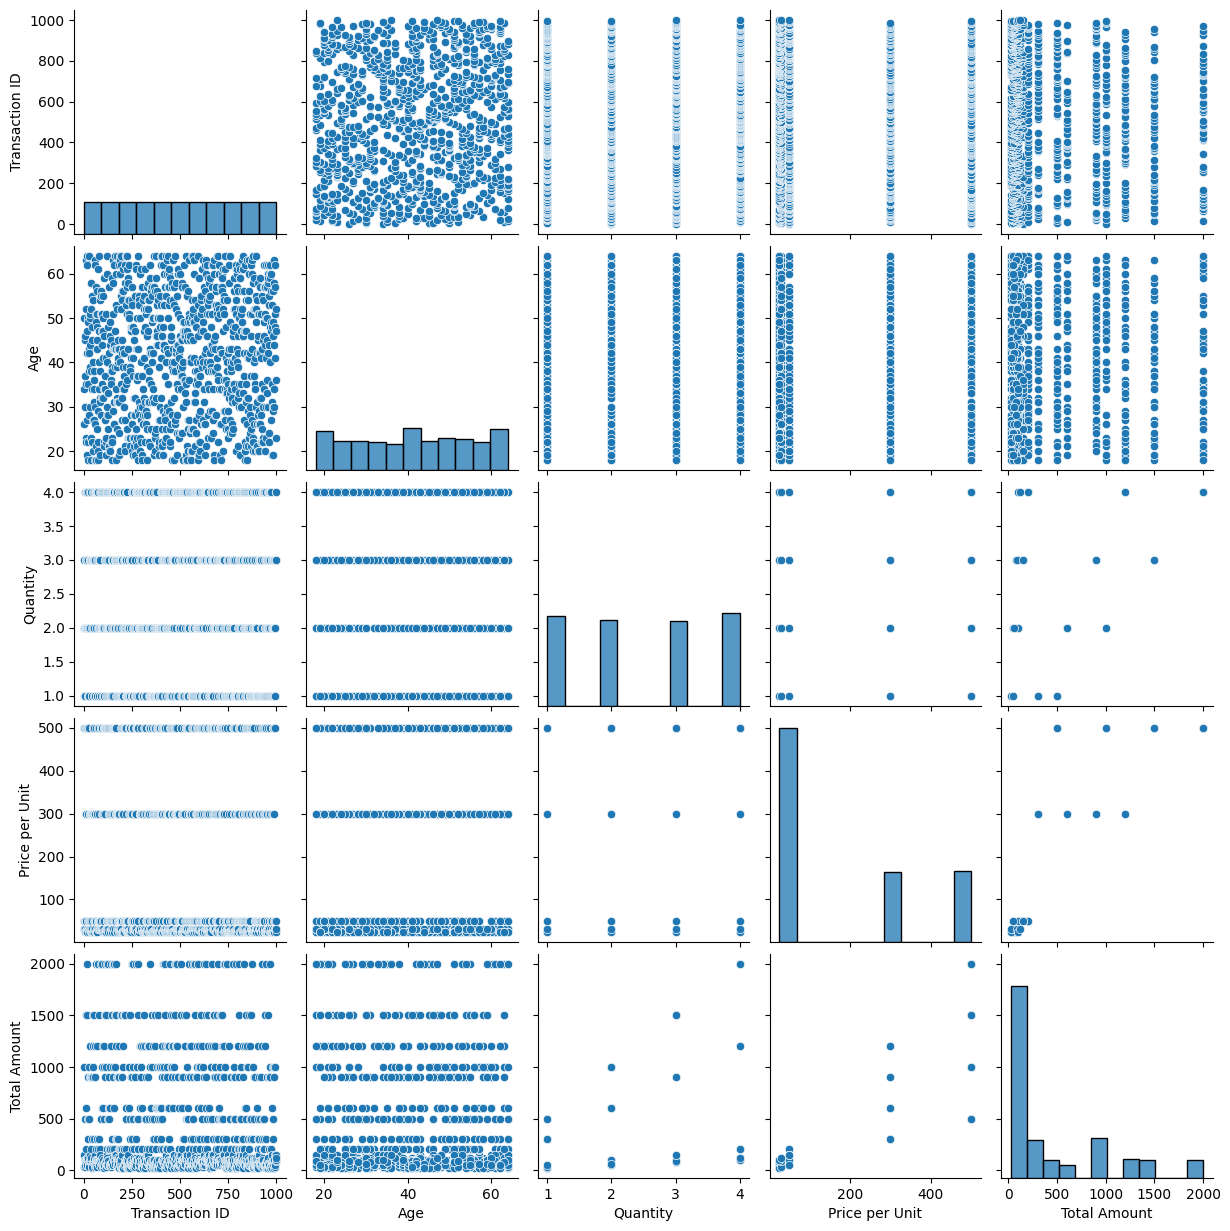

In [ ]:
sns.pairplot(data=df)

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

# Calculate the number of duplicate rows
num_duplicates = df.duplicated().sum()

if num_duplicates > 0:
  df.drop_duplicates(inplace=True)
  print(f"Dropped {num_duplicates} duplicate rows.")

# Check for missing values after potential duplicate removal
# 'df.isnull().any().any()' checks if there are any True values (NaNs) in the entire DataFrame
if df.isnull().any().any():
   df.dropna(inplace=True)
   print("Dropped rows with missing value")

In [ ]:
#Pie Chart
#Gender Distribution
df1 = df['Gender']
fig = px.pie(df1,
             names='Gender',
             title='Gender Distribution')
fig.show()

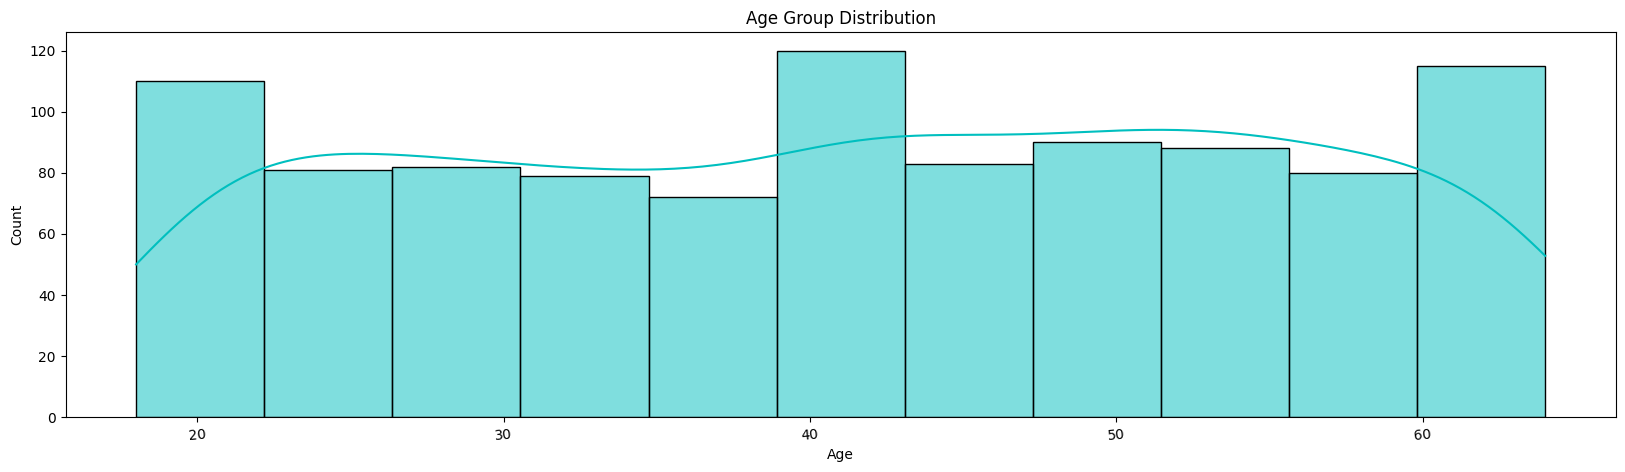

In [ ]:
#Histogram Plot
#Age Group Distribution
plt.figure(figsize=(20,5))
sns.histplot(data=df,
             x=df['Age'].sort_values(),
             kde=True,
             color='c')
plt.title('Age Group Distribution')
plt.xticks(rotation=5)
plt.show()

In [ ]:
#Violin plot
#Gender & Age Group Distribution
plot = px.violin(x=df['Gender'],
                 y=df['Age'],
                 box=True,
                 points='all')
plot.update_traces(
    box_fillcolor='green',
    opacity=0.5
)
plot.update_layout(
    title='Gender & Age Group Distribution',
    xaxis_title='Gender',
    yaxis_title='Age Group'
)

plot.show()

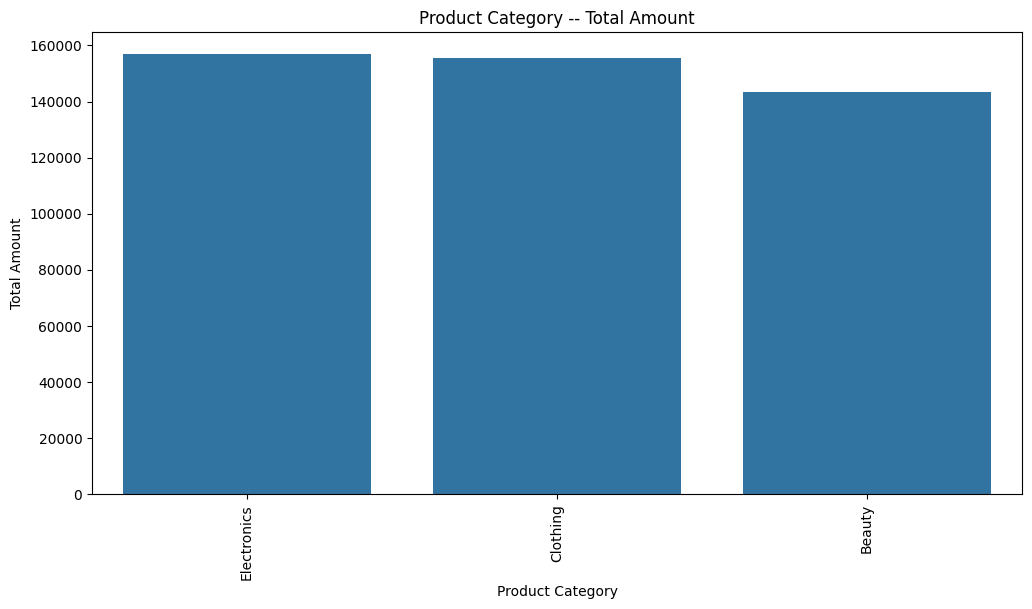

In [ ]:
#Bar Plot
#Gold_Item_net_wt_sum
Gold_item_net_wt = df.groupby('Product Category')['Total Amount'].sum().nlargest(40)
plt.figure(figsize=(12, 6))
sns.barplot(
    x=Gold_item_net_wt.index,
    y=Gold_item_net_wt.values)
plt.xticks(rotation=90)
plt.title("Product Category -- Total Amount")
plt.xlabel("Product Category")
plt.ylabel("Total Amount")
plt.show()

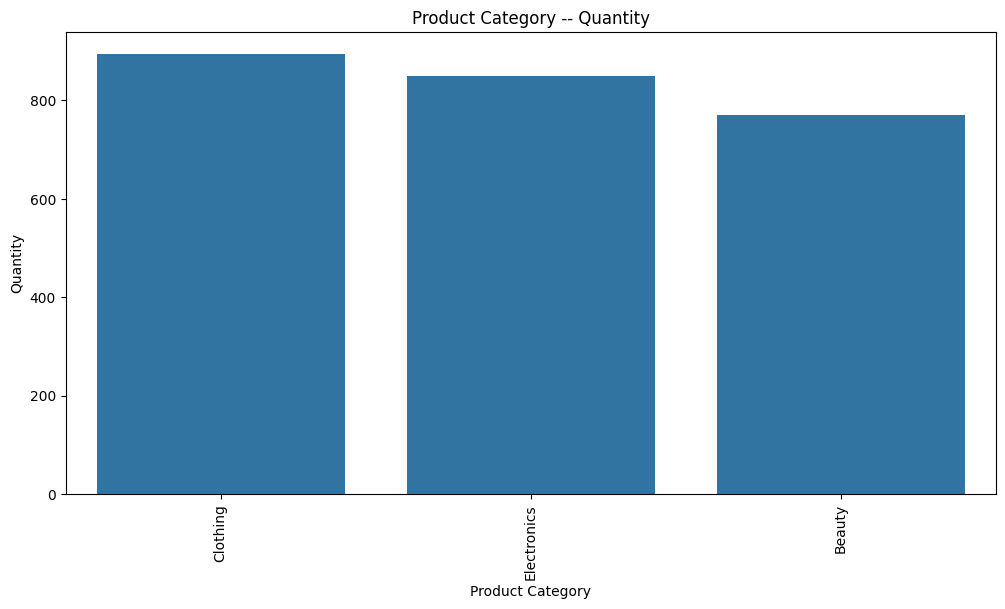

In [ ]:
#Bar Plot
#Gold_Item_net_wt_sum
Gold_item_net_wt = df.groupby('Product Category')['Quantity'].sum().nlargest(40)
plt.figure(figsize=(12, 6))
sns.barplot(
    x=Gold_item_net_wt.index,
    y=Gold_item_net_wt.values)
plt.xticks(rotation=90)
plt.title("Product Category -- Quantity")
plt.xlabel("Product Category")
plt.ylabel("Quantity")
plt.show()

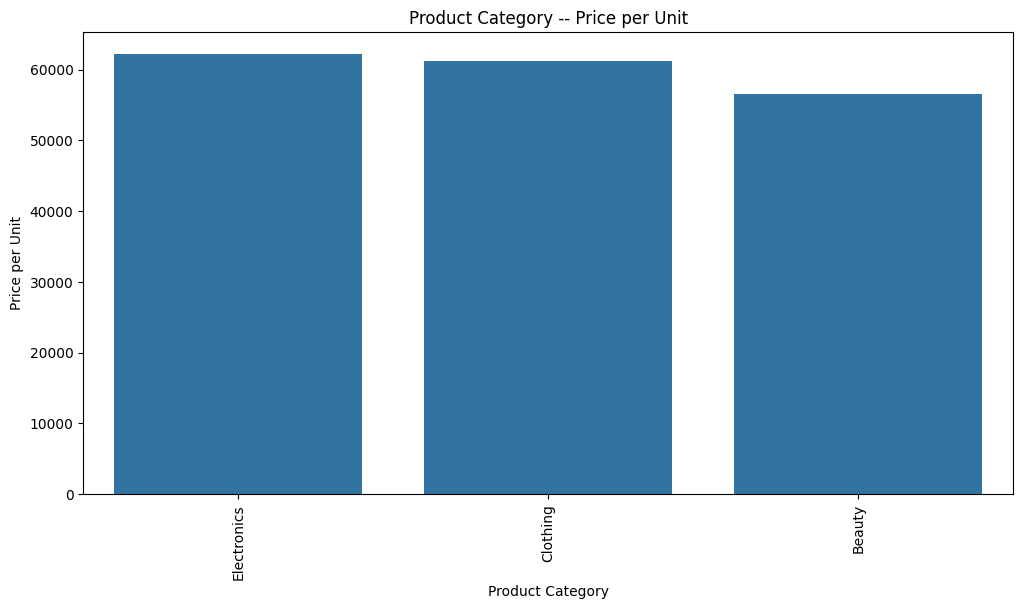

In [ ]:
#Bar Plot
#Gold_Item_net_wt_sum
Gold_item_net_wt = df.groupby('Product Category')['Price per Unit'].sum().nlargest(40)
plt.figure(figsize=(12, 6))
sns.barplot(
    x=Gold_item_net_wt.index,
    y=Gold_item_net_wt.values)
plt.xticks(rotation=90)
plt.title("Product Category -- Price per Unit")
plt.xlabel("Product Category")
plt.ylabel("Price per Unit")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

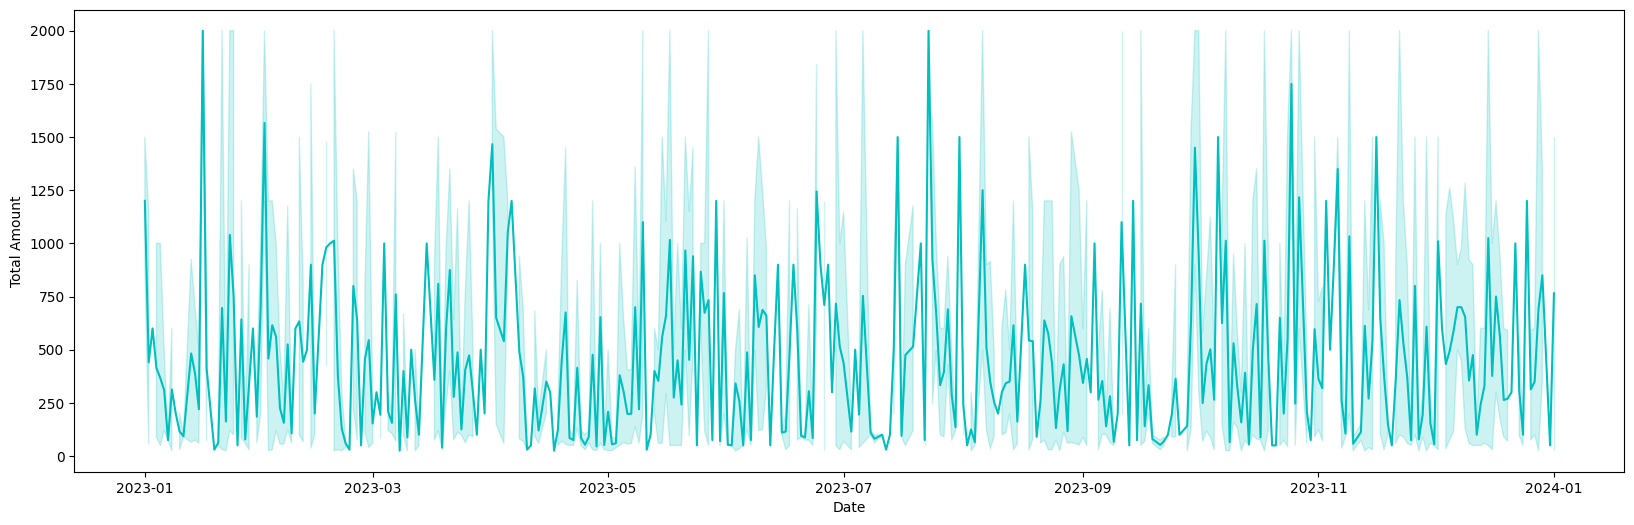

In [ ]:
plt.figure(figsize=(20,6))
sns.lineplot(data=df,x=df['Date'],y=df['Total Amount'],color='c')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

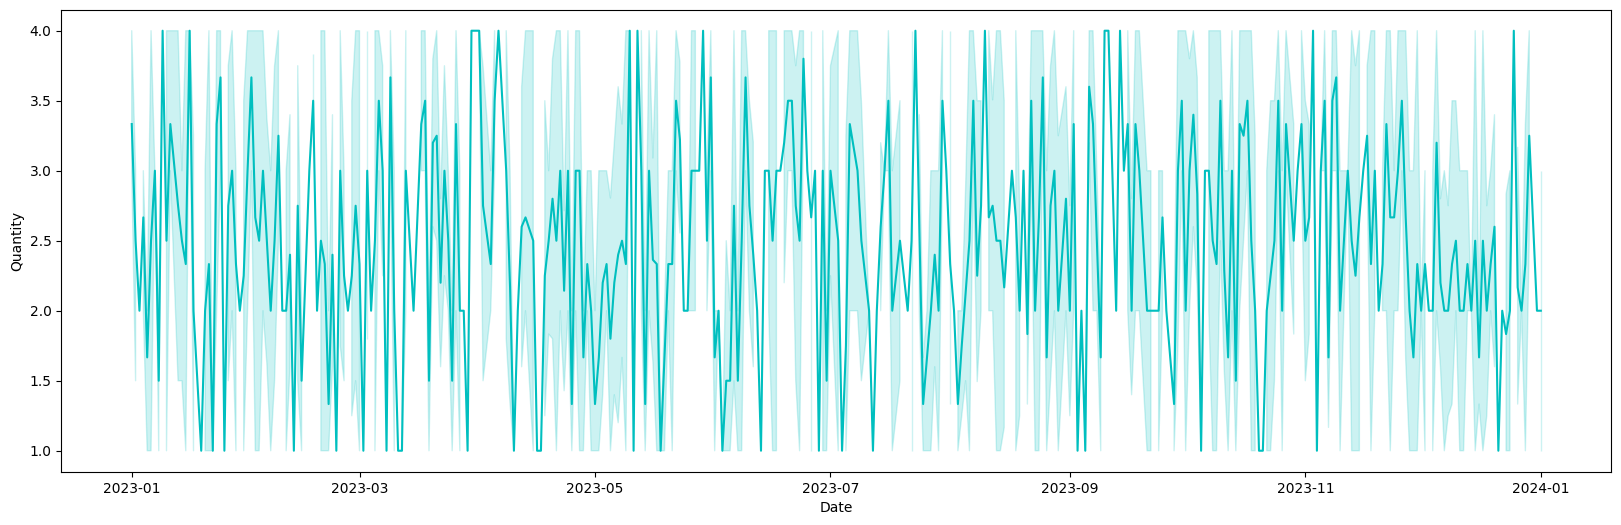

In [ ]:
plt.figure(figsize=(20,6))
sns.lineplot(data=df,x=df['Date'],y=df['Quantity'],color='c')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

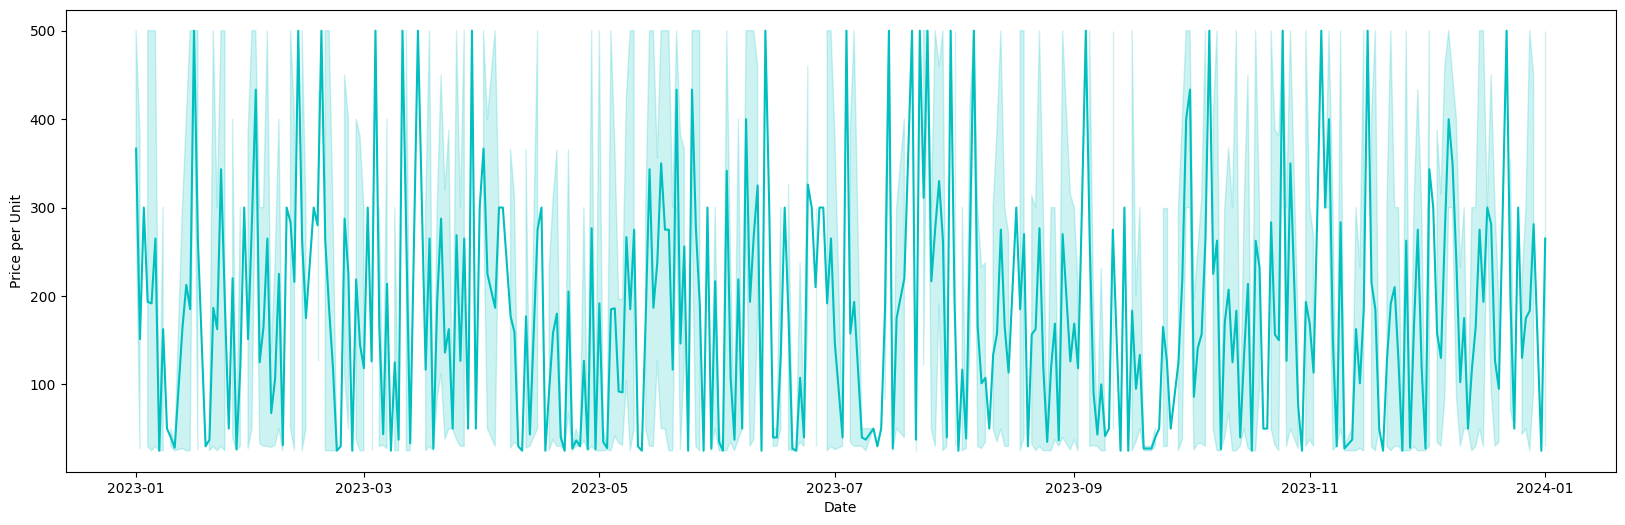

In [ ]:
plt.figure(figsize=(20,6))
sns.lineplot(data=df,x=df['Date'],y=df['Price per Unit'],color='c')
plt.show

In [ ]:
# First, define X and y from the DataFrame
# Assuming 'Total Amount' is the target variable
# And dropping identifier columns and 'Date' for feature set X
X = df.drop(['Transaction ID', 'Customer ID', 'Date', 'Total Amount'], axis=1)
y = df['Total Amount']

# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Now, X_train is defined, and we can proceed to get cat columns and num columns for extra encoding purpose
num_cols=[col for col in X_train.columns if X_train[col].dtype!='O']
cat_cols=[col for col in X_train.columns if X_train[col].dtype=='O']

In [ ]:
#numerical processing pipeline
numeric_processor=Pipeline(
    steps=[
           ("scaler",StandardScaler())]
)

#categorical processing
from sklearn.preprocessing import OneHotEncoder
categorical_processor=Pipeline(
    steps=[
           ("onehot",OneHotEncoder(handle_unknown='ignore'))]
)